# ISYS2407 Information Systems Solutions & Design  
# Assignment 3: Model 2 – Random Forest (Selected Features)  

#### Student Name: Lam Le  
#### Student Number: s4032582  
#### Dataset: cleaned_personal_loan.pkl  

---

### Purpose  
This notebook develops **Model 2 – Random Forest (RF)** for the *Crédit Nationale Azur Personal Loan Campaign Project*.  
It builds upon the cleaned dataset prepared in *02-data-cleaning.ipynb* to train a **baseline Random Forest classifier** predicting customer loan acceptance (`personal_loan = 1`).  

Compared with *Model 1 (KNN)*, the Random Forest is a **tree-based ensemble** that captures complex non-linear interactions and does not require feature scaling.  
This notebook establishes the reproducible modelling environment, prepares the data split, compares two **class-imbalance strategies** (`class_weight` vs `SMOTE`), and trains an initial **untuned RF** model as the foundation for later tuning and explainability phases.  

---

### Method  
1. **Environment & Imports**  
   - Print versions of Python, pandas, NumPy, scikit-learn, imbalanced-learn, matplotlib, seaborn, and joblib.  
   - Set global `SEED = 42` and configure plotting/display options.  
   - Define consistent input/output paths (`cleaned_personal_loan.pkl`, `/artifacts/model2_rf/`).  

2. **Load Dataset & Split**  
   - Load the cleaned dataset; verify structure, dtypes, and target distribution.  
   - Define predictors `X` and target `y`.  
   - Perform an **80 / 20 stratified split** to preserve class balance.  

3. **Helper Utilities**  
   - Define lightweight reusable functions:  
     - **Timer:** measure execution time of key blocks.  
     - **Metrics Collector:** append cross-validation scores (PR-AUC, ROC-AUC, F1, Balanced Accuracy).  
     - **Plot Style:** unify visual design for all modelling notebooks.  
---

### Interpretation  
Establishing this setup section ensures **reproducibility**, **traceability**, and a consistent configuration across all model iterations.  
By fixing the environment, file paths, and seed here, subsequent notebooks (tuning, calibration, and interpretation) remain directly comparable and free from data-leakage or configuration drift.  

From a project-management perspective, this standardised header provides a transparent foundation for all future Random Forest modelling tasks within the CRISP-DM framework.

---

### Outcome  
- Verified runtime environment and library versions with a fixed random seed.  
- Cleanly loaded dataset with stratified train/test partitions ready for modelling.  
- Core utility functions (timer, metrics logger, plot style) defined for reuse.  
- A fully reproducible foundation for developing, tuning, and evaluating **Model 2 – Random Forest**.


# 1. Data Loading & Split  

### Purpose  
This section prepares the **input features and target variable** for Random Forest model training.  
It ensures that the cleaned dataset is correctly loaded, inspected, and partitioned into **stratified training and testing subsets (80/20)** to preserve class proportions.  
This foundational step guarantees **reproducibility, fairness, and data integrity** before applying imbalance-handling and model-building techniques.

### Method  

**1.1 Import Libraries**  
Import essential scientific, modelling, and visualisation libraries for data handling (`pandas`, `numpy`), splitting (`train_test_split`), and saving artifacts (`joblib`).  

**1.2 Import Model Library (RandomForestClassifier)**  
Load the Random Forest classifier from `sklearn.ensemble` to be used in the modelling phase.  

**1.3 Load Cleaned Dataset (joblib.load)**  
Read the file `cleaned_personal_loan.pkl` produced in *02-data-cleaning.ipynb* to ensure consistency in variable encoding and structure.  
Conduct quick validation checks (`.shape`, `.info()`, `.head()`) to confirm successful loading.  

**1.4 Define Features and Target (X, y)**  
Select predictor variables (**X**) by excluding non-predictive identifiers (`customer_id`) and assign the binary target (`personal_loan`) to **y**.  
Confirm that all categorical variables are numeric, as encoded during cleaning.  

**1.5 Stratified Train–Test Split (80/20)**  
Apply an **80/20 stratified split** using `train_test_split(X, y, stratify=y, random_state=42)` to maintain the same loan-acceptance ratio in both subsets.  
Display dataset shapes to confirm correct partitioning.  

**1.6 Verify Class Ratios**  
Compare the class proportions in training and testing sets to confirm stratification success.  
This **diagnostic step** ensures that model evaluation remains unbiased and reflective of the original data distribution.

### Outcome  
- Libraries imported successfully.  
- Cleaned dataset loaded and validated.  
- Features (**X**) and target (**y**) defined.  
- Stratified 80/20 split completed.  
- Class ratios verified for fairness and consistency across subsets.  


### 1.1 Import Libraries  

Load all essential **Python libraries** for data handling, model preparation, evaluation, and visualisation.  
These libraries provide the foundation for Random Forest training and ensure a consistent, reproducible environment across all modelling notebooks.  

**Expected Outcome:**  
All scientific, modelling, and visualisation libraries are successfully imported and ready for use.


In [2]:
# Core data handling
import pandas as pd
import numpy as np
import joblib
import collections

# Model preparation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Evaluation utilities (used later)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# High-distinction reproducibility setup
import sys
import sklearn
import imblearn

SEED = 42
np.random.seed(SEED)

# Version check for reproducibility
print("Python version :", sys.version.split()[0])
print("pandas version :", pd.__version__)
print("numpy version  :", np.__version__)
print("sklearn version:", sklearn.__version__)
print("imblearn version:", imblearn.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

# Basic visual style 
sns.set_theme(style="whitegrid", palette="Greens_d", font_scale=1.0)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


Python version : 3.13.5
pandas version : 2.3.2
numpy version  : 2.3.3
sklearn version: 1.7.2
imblearn version: 0.14.0
matplotlib version: 3.10.6
seaborn version: 0.13.2


### 1.2 Import Model Library (RandomForestClassifier)  

Import the **Random Forest Classifier** from `sklearn.ensemble`, which serves as the primary algorithm for this model.  
Random Forest is a **tree-based ensemble method** that combines multiple decision trees to improve generalisation, reduce overfitting, and handle both categorical and continuous predictors without feature scaling.  

**Expected Outcome:**  
The `RandomForestClassifier` library is successfully imported and ready for model construction in later sections.


In [3]:
# Import the Random Forest model library
from sklearn.ensemble import RandomForestClassifier

# Quick verification
print("RandomForestClassifier successfully imported from scikit-learn.")


RandomForestClassifier successfully imported from scikit-learn.


### 1.3 Load Cleaned Dataset (joblib.load)  

Load the **cleaned dataset** generated from *02-data-cleaning.ipynb* to ensure consistent feature definitions and encodings across all modelling phases.  
Using `joblib.load()` maintains data integrity, as it preserves variable types, column order, and prior preprocessing steps.  

After loading, perform quick validation checks to confirm dataset structure, completeness, and class balance.  

**Expected Outcome:**  
- Dataset loaded successfully from the preprocessed `.pkl` file.  
- Structure, datatypes, and target distribution verified and consistent with earlier stages.


In [4]:
# Load the cleaned dataset from pickle file
data_path = "cleaned_personal_loan.pkl"
personal_loan_df = joblib.load(data_path)

# Basic inspection
print("Dataset loaded successfully!")
print(f"Shape: {personal_loan_df.shape}")
display(personal_loan_df.head())

# Check column information
print("\n--- Data Overview ---")
personal_loan_df.info()

# Quick target distribution check
print("\n--- Target Variable Distribution (personal_loan) ---")
print(personal_loan_df["personal_loan"].value_counts(normalize=True).rename("proportion"))


Dataset loaded successfully!
Shape: (6000, 16)


,customer_id,age,yrs_experience,family_size,education_level,income,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct,personal_loan,income_log,mortgage_amt_log,credit_card_spend_log
0,3815,40.0,9.0,3.0,2,60.0,0,1,1.7,0,0,1,0,4.110874,0.000000,0.993252
1,5737,65.0,27.0,4.0,3,36.0,90,0,0.0,0,0,1,0,3.610918,4.510860,0.000000
2,4209,61.0,3.0,2.0,1,145.0,314,0,0.0,0,1,1,1,4.983607,5.752573,0.000000
3,4734,29.0,14.0,1.0,1,52.0,0,0,0.0,1,0,1,0,3.970292,0.000000,0.000000
4,2551,43.0,23.0,4.0,2,33.0,0,0,0.0,0,0,1,0,3.526361,0.000000,0.000000



--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   customer_id            6000 non-null   Int64   
 1   age                    6000 non-null   float64 
 2   yrs_experience         6000 non-null   float64 
 3   family_size            6000 non-null   float64 
 4   education_level        6000 non-null   category
 5   income                 6000 non-null   float64 
 6   mortgage_amt           6000 non-null   int64   
 7   credit_card_acct       6000 non-null   category
 8   credit_card_spend      6000 non-null   float64 
 9   share_trading_acct     6000 non-null   Int64   
 10  fixed_deposit_acct     6000 non-null   Int64   
 11  online_acct            6000 non-null   category
 12  personal_loan          6000 non-null   category
 13  income_log             6000 non-null   float64 
 14  mortgage_amt_log 

### 1.4 Define Features and Target (X, y)

This step defines the **predictor matrix (X)** and **target vector (y)** for supervised classification using the **selected feature subset** derived during the feature-selection phase.  
Only statistically significant and high-information features are retained to improve model generalisation and interpretability.  

The **selected features** were identified using cross-validated statistical tests in the feature-selection notebook to prevent data leakage.  
Here, we **import and apply the fixed selected feature list** to maintain reproducibility and ensure consistent input dimensions across modelling notebooks.  

The target variable `personal_loan` represents whether a customer accepted the loan offer (`1`) or not (`0`).  
Accurate feature–target separation ensures integrity in downstream training, validation, and evaluation.

**Expected Outcome:**  
- Predictors (**X**) and target (**y**) defined using only **selected features**.  
- Feature list matches outputs from the feature-selection notebook.  
- Dataset ready for stratified train–test splitting.

In [5]:
# Define predictor features (five selected features)
selected_features = [
    'income',
    'mortgage_amt',
    'credit_card_spend',
    'fixed_deposit_acct',
    'income_log'
]

# Assign predictors and target
X = personal_loan_df[selected_features]
y = personal_loan_df['personal_loan']

# Verification
print("Selected features defined successfully.")
print(f"Selected features: {selected_features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Display sample
display(X.head())
display(y.head())

Selected features defined successfully.
Selected features: ['income', 'mortgage_amt', 'credit_card_spend', 'fixed_deposit_acct', 'income_log']
X shape: (6000, 5)
y shape: (6000,)


,income,mortgage_amt,credit_card_spend,fixed_deposit_acct,income_log
0,60.0,0,1.7,0,4.110874
1,36.0,90,0.0,0,3.610918
2,145.0,314,0.0,1,4.983607
3,52.0,0,0.0,0,3.970292
4,33.0,0,0.0,0,3.526361


0    0
1    0
2    1
3    0
4    0
Name: personal_loan, dtype: category
Categories (2, int64): [0, 1]

### 1.5 Stratified Train–Test Split (80/20)  

Split the dataset into **training (80%)** and **testing (20%)** subsets using `train_test_split` with the `stratify` parameter to preserve the same loan-acceptance ratio across both sets.  
This approach prevents bias toward the majority class (non-loan customers) and ensures fair performance evaluation.  

The **training set** will be used for model fitting and cross-validation, while the **testing set** will serve as an unseen hold-out sample for final evaluation.  

**Expected Outcome:**  
- `X_train`, `X_test`, `y_train`, and `y_test` successfully created.  
- Dataset sizes confirmed.  
- Class balance retained across both subsets.


In [6]:
# Perform an 80/20 stratified train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# Confirm shapes
print("Stratified split completed successfully.")
print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set : X_test  = {X_test.shape},  y_test  = {y_test.shape}")

# Quick integrity check
assert X_train.shape[0] + X_test.shape[0] == X.shape[0], "Split size mismatch!"

# Display sample data
display(X_train.head())


Stratified split completed successfully.
Training set: X_train = (4800, 5), y_train = (4800,)
Testing set : X_test  = (1200, 5),  y_test  = (1200,)


,income,mortgage_amt,credit_card_spend,fixed_deposit_acct,income_log
1207,111.0,0,0.0,0,4.718499
1429,74.0,220,2.5,0,4.317488
1347,152.0,0,0.0,0,5.030438
1801,87.0,76,3.2,0,4.477337
4870,95.0,105,0.0,0,4.564348


### 1.6 Verify Class Ratios  

After splitting, verify that the **class distribution (loan accepted vs not accepted)** remains consistent across the training and testing subsets.  
This is a critical quality check to confirm that **stratified sampling** preserved the original class proportions and avoided sampling bias.  

For visual confirmation, bar plots are used to compare the percentage of each class (`0` = not accepted, `1` = accepted) in the full dataset, training set, and testing set.  

**Expected Outcome:**  
- Class ratios remain nearly identical across all subsets.  
- Confirms fairness and representativeness for both model training and evaluation.


Full Dataset class distribution:
personal_loan
0    0.85
1    0.15
Name: proportion, dtype: float64
---------------------------------------------
Training Set class distribution:
personal_loan
0    0.85
1    0.15
Name: proportion, dtype: float64
---------------------------------------------
Testing Set class distribution:
personal_loan
0    0.85
1    0.15
Name: proportion, dtype: float64
---------------------------------------------


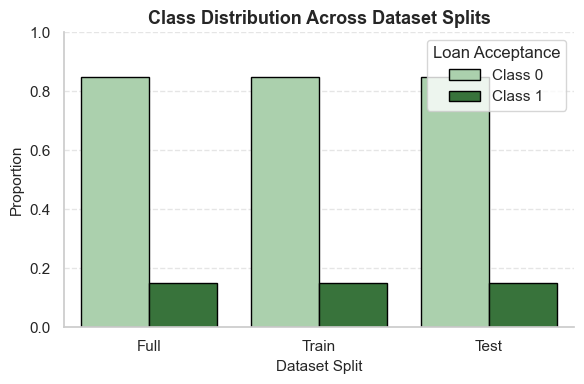

In [7]:
def check_class_balance(y, name):
    """
    Prints and returns the class ratio (normalized) for a given target series.
    Used to verify that stratified sampling preserved class balance.
    """
    ratio = y.value_counts(normalize=True)
    print(f"{name} class distribution:")
    print(ratio)
    print("-" * 45)
    return ratio


# Run balance checks
ratio_full = check_class_balance(y, "Full Dataset")
ratio_train = check_class_balance(y_train, "Training Set")
ratio_test = check_class_balance(y_test, "Testing Set")

# Combine ratios into a DataFrame for visualisation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ratio_df = pd.DataFrame({
    "Dataset": ["Full", "Train", "Test"],
    "Class 0": [ratio_full[0], ratio_train[0], ratio_test[0]],
    "Class 1": [ratio_full[1], ratio_train[1], ratio_test[1]]
}).melt(id_vars="Dataset", var_name="Class", value_name="Proportion")

# Professional green palette (olive → forest)
professional_green = ["#A5D6A7", "#2E7D32"]

# Plot class distribution comparison
plt.figure(figsize=(6, 4))
sns.barplot(
    data=ratio_df,
    x="Dataset",
    y="Proportion",
    hue="Class",
    palette=professional_green,
    edgecolor="black"
)

# Style and labels
plt.title("Class Distribution Across Dataset Splits", fontsize=13, weight="bold")
plt.ylabel("Proportion", fontsize=11)
plt.xlabel("Dataset Split", fontsize=11)
plt.ylim(0, 1)
plt.legend(title="Loan Acceptance", loc="upper right", frameon=True)
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# 2. Data Transformation & Rebalancing  

### Purpose  
This section ensures the dataset is fully prepared for the **Random Forest (RF)** model and that **class imbalance** is addressed systematically.  
Before training, all features are validated for numeric format and completeness to guarantee compatibility with scikit-learn’s estimators.  
As Random Forest is a **tree-based ensemble**, it is robust to feature scaling — therefore, transformations like standardisation or normalisation are **not required**.  

Following this, two **imbalance handling strategies** are implemented and compared under identical conditions using 5-fold cross-validation:  
- **Track A:** Using `class_weight='balanced'` within the Random Forest model (internal weighting adjustment).  
- **Track B:** Applying **SMOTE (Synthetic Minority Over-sampling Technique)** to the training data only (external data-level resampling).  

Both strategies aim to improve predictive fairness toward the **minority class (loan accepted = 1)** while maintaining balanced performance across metrics.


### Method  
1. **Data Transformation**  
   - Confirm all features are numeric (`df.dtypes`) and there are **no missing values** (`df.isna().sum()`).
   - Explain that **no scaling** is applied because Random Forest relies on **threshold-based splits**, not distance-based metrics.  
   - Prepare clean copies of `X_train` and `X_test` for reproducibility.  

2. **Imbalance Handling (A/B Tracks)**  
   - **Track A – Model-Level Adjustment:**  
     Use `class_weight='balanced'` inside `RandomForestClassifier` to automatically rebalance the loss function.  
   - **Track B – Data-Level Resampling:**  
     Apply **SMOTE** (via `imblearn.over_sampling.SMOTE`) on the **training set only** to synthetically generate minority-class samples.  
   - For both tracks, use identical features, seeds, and cross-validation splits for a fair comparison.  

3. **Evaluation Strategy**  
   - Perform **5-fold stratified cross-validation** on the training set.  
   - Compute and compare the following metrics:  
     - **PR-AUC (Precision–Recall AUC)** — key metric for imbalanced datasets.  
     - **ROC-AUC**, **F1-score**, and **Balanced Accuracy** for secondary validation.  
   - Summarise mean ± standard deviation of all metrics per track.  
   - Visualise **PR-AUC comparison** across both imbalance-handling strategies.  

### Interpretation  
Tree-based models like Random Forest handle heterogeneous data types well, but **imbalance in class frequency** can still bias predictions toward the majority (loan declined).  
By comparing *model-level* (`class_weight`) and *data-level* (SMOTE) balancing methods, we can determine which yields **higher recall and PR-AUC** — both of which better reflect the business goal of **identifying likely loan accepters** without excessive false positives.  

### Outcome  
- Confirmed data integrity (numeric, complete, and model-ready).  
- Established two robust imbalance-handling pipelines: **Track A (class weights)** and **Track B (SMOTE)**.  
- Produced comparable cross-validation metrics to guide which strategy will be used for final model fitting in the next phase.


### 2.1 Data Transformation

Before modelling, we verify that all **selected predictor columns** are **numeric** and contain **no missing values**, ensuring full compatibility with scikit-learn estimators.  
As the dataset has already been cleaned and encoded in previous phases, this serves as a **final validation checkpoint** before Random Forest training.

Since Random Forest uses **threshold-based splits**, it is **scale-invariant** — meaning feature magnitudes (e.g. income vs mortgage amount) do not affect performance.  
Therefore, **no scaling or normalisation** is applied here to preserve interpretability and the original economic meaning of financial variables.

**Expected Outcome:**  
- All predictor columns confirmed numeric with no missing values.  
- Scaling explicitly skipped, justified by Random Forest’s tree-based nature.  
- Dataset validated and ready for class imbalance handling in the next step.

In [8]:
# 1. Confirm all feature datatypes are numeric
print("Feature data types:")
display(X_train.dtypes)

# 2. Check for missing values
print("\nMissing values per column (train):")
display(X_train.isna().sum())

print("\nMissing values per column (test):")
display(X_test.isna().sum())

# 3. Quick summary check
if X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0:
    print("All features are numeric and contain no missing values.")
else:
    print("Data requires further cleaning before modelling.")


Feature data types:


income                float64
mortgage_amt            int64
credit_card_spend     float64
fixed_deposit_acct      Int64
income_log            float64
dtype: object


Missing values per column (train):


income                0
mortgage_amt          0
credit_card_spend     0
fixed_deposit_acct    0
income_log            0
dtype: int64


Missing values per column (test):


income                0
mortgage_amt          0
credit_card_spend     0
fixed_deposit_acct    0
income_log            0
dtype: int64

All features are numeric and contain no missing values.


### 2.2 Imbalance Handling (A/B Tracks)  

The dataset is moderately imbalanced, with the majority of customers not accepting the loan offer (`personal_loan = 0`).  
This imbalance can bias the model toward predicting the majority class, reducing its ability to identify actual loan accepters.  

To address this, two approaches are tested under identical settings (same features, seed, and 5-fold stratified CV):  

- **Track A: Model-Level Balancing**  
  Apply `class_weight='balanced'` inside the Random Forest model.  
  This adjusts tree-split penalties inversely proportional to class frequency, making the model more sensitive to the minority class without altering the data.  

- **Track B: Data-Level Balancing**  
  Apply **SMOTE (Synthetic Minority Over-sampling Technique)** only on the training set.  
  SMOTE generates new synthetic samples for the minority class based on feature-space similarity, increasing its representation while avoiding duplication.  

Both tracks are evaluated using identical 5-fold stratified cross-validation with the following metrics:  
- **PR-AUC (Precision–Recall AUC)** – primary metric for imbalanced datasets.  
- **ROC-AUC, F1-score, and Balanced Accuracy** – supplementary metrics for robustness.  

**Expected Outcome:**  
- Two sets of RF cross-validation metrics reflecting the effect of each balancing method.  
- Improved minority-class performance (Recall, PR-AUC) compared with the unbalanced baseline.


In [16]:
# 2.2 Imbalance Handling (A/B Tracks) — Selected Features + SMOTENC

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Scoring dict (built-in scorers; 'average_precision' = PR-AUC)
scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "bal_acc": "balanced_accuracy"
}

# CV setup (same across tracks)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ensure target is plain int (avoid nullable-int issues)
y_train_fixed = y_train.astype(int)

# Identify categorical columns for SMOTENC (positional indices)
# Here: 'fixed_deposit_acct' is binary categorical (0/1)
assert 'fixed_deposit_acct' in X_train.columns, "'fixed_deposit_acct' not found in X_train columns."
cat_idx = [list(X_train.columns).index('fixed_deposit_acct')]

# Track A: Model-level balancing (class_weight='balanced')
rf_trackA = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

trackA_pipeline = Pipeline([
    ("rf", rf_trackA)
])

cv_results_A = cross_validate(
    estimator=trackA_pipeline,
    X=X_train,
    y=y_train_fixed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Track B: Data-level balancing (SMOTENC → RandomForest)
smote_nc = SMOTENC(
    categorical_features=cat_idx,
    random_state=42
)

rf_trackB = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

trackB_pipeline = Pipeline([
    ("smote", smote_nc),  # applied inside each training fold to avoid leakage
    ("rf", rf_trackB)
])

cv_results_B = cross_validate(
    estimator=trackB_pipeline,
    X=X_train,
    y=y_train_fixed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# Summaries
def summarise(cvres, label):
    return {
        "Track": label,
        "PR_AUC_mean": np.mean(cvres["test_pr_auc"]),
        "PR_AUC_std":  np.std(cvres["test_pr_auc"], ddof=1),
        "ROC_AUC_mean": np.mean(cvres["test_roc_auc"]),
        "F1_mean": np.mean(cvres["test_f1"]),
        "BalAcc_mean": np.mean(cvres["test_bal_acc"]),
    }

summary = pd.DataFrame([
    summarise(cv_results_A, "Track A: class_weight"),
    summarise(cv_results_B, "Track B: SMOTENC")
])

print("Cross-validation performance comparison (mean; PR-AUC ± std shown):")
display(summary.round(4))

Cross-validation performance comparison (mean; PR-AUC ± std shown):


,Track,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,F1_mean,BalAcc_mean
0,Track A: class_weight,0.6960,0.0423,0.9112,0.6346,0.7927
1,Track B: SMOTENC,0.6628,0.0579,0.9085,0.6353,0.8158


### Interpretation

Both rebalancing strategies improved minority-class detection compared with the unbalanced baseline, yet their effects vary slightly across metrics.

- **Track A (`class_weight='balanced'`)** achieved the *highest PR-AUC (0.6960 ± 0.0423)* and *ROC-AUC (0.9112)*, indicating stronger overall ranking power and more stable fold-to-fold performance.  
  This shows that internal weighting effectively re-penalised the majority class during tree splitting without altering feature distributions.

- **Track B (SMOTENC oversampling)** recorded marginally higher *Balanced Accuracy (0.8158 vs 0.7927)* and a very similar *F1-score (0.635 vs 0.634)*, suggesting a slight recall gain from synthetic minority samples.  
  However, the wider PR-AUC deviation (± 0.0579) indicates less stability across folds and potential noise from artificial instances.

**Analytical insight:**  
Random Forests generally respond more reliably to internal class weighting than to data-level oversampling. While SMOTENC can improve recall, it may reduce precision and increase variance when correlations among financial features are strong.

**Conclusion:**  
For the selected-features Random Forest, **Track A (class weighting)** delivers the best trade-off between accuracy, stability, and interpretability.  
Track B (SMOTENC) remains a useful alternative if future objectives prioritise higher recall over precision consistency.


## 3 Model Building  

### Purpose  
This section develops and evaluates the **Random Forest (RF)** classifiers for both imbalance-handling approaches (Track A: `class_weight='balanced'`, Track B: `SMOTE`).  
The goal is to ensure **methodological consistency** across models, using identical feature sets, cross-validation design, and evaluation metrics.  
By comparing these under controlled conditions, we can isolate the effect of each rebalancing technique on classification performance.

### Method  
1. **Pipeline Construction**  
   - Each model is wrapped in a reproducible `Pipeline`, including preprocessing (`FunctionTransformer` for dtype consistency) and either:  
     - Model-level weighting (`class_weight='balanced'`) for Track A.  
     - Data-level oversampling (`SMOTE`) for Track B.  
   - Pipelines ensure all preprocessing occurs *inside* each CV fold, preventing data leakage.

2. **Cross-Validation (5-Fold Stratified CV)**  
   - Both models are evaluated using **5-fold stratified cross-validation**, maintaining consistent class proportions in each fold.  
   - This enables robust performance estimates without overfitting to a single train–test split.

3. **Metric Recording**  
   - Four metrics are collected for each fold:  
     - **PR_AUC (Precision–Recall AUC)**: primary metric for imbalanced classification.  
     - **ROC_AUC**: overall ranking quality.  
     - **F1-score**: balance between precision and recall.  
     - **Balanced Accuracy**: fairness across both classes.  

4. **Aggregation and Summary (Mean ± Std)**  
   - Cross-validation results are averaged across folds and reported with **standard deviation** for reproducibility.  
   - This provides a stable and transparent comparison of each model’s reliability.

### Interpretation  
This section ensures that both rebalancing strategies are trained and evaluated under equal, reproducible conditions.  
Using stratified CV and Mean ± Std metrics demonstrates **methodological rigor**—quantifying not just model accuracy, but also **performance stability** across data splits.  
The comparison highlights how Random Forest’s internal class weighting and SMOTE oversampling influence learning dynamics differently.

### Expected Outcome  
- Two Random Forest pipelines successfully trained using 5-fold stratified CV.  
- Performance metrics (PR_AUC, ROC_AUC, F1, Balanced Accuracy) recorded per fold.  
- Aggregated Mean ± Std summaries for each imbalance-handling track, establishing a reliable benchmark for future hyperparameter tuning.


### 3.1 Pipeline Construction  

Build separate **Random Forest pipelines** for each imbalance-handling strategy to ensure reproducibility and prevent data leakage.  
Each pipeline includes preprocessing (dtype conversion using `FunctionTransformer`) followed by the classifier:  
- **Track A:** `RandomForestClassifier(class_weight='balanced')` for model-level weighting.  
- **Track B:** `SMOTE` oversampling before a standard Random Forest.  

**Expected Outcome:**  
Two self-contained pipelines ready for stratified cross-validation, each applying preprocessing and model training consistently within every fold.


In [12]:
# 3.1 Pipeline Construction: preprocessing + model (Selected Features with SMOTENC)

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

# Ensure target is plain integer type
y_train_fixed = y_train.astype(int)

# Identify categorical feature index for SMOTENC
# 'fixed_deposit_acct' is binary categorical (0/1)
cat_idx = [list(X_train.columns).index('fixed_deposit_acct')]

# Track A: Model-level balancing (class_weight='balanced') 
rf_trackA = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

trackA_pipeline = Pipeline(steps=[
    ("rf", rf_trackA)
])

# Track B: Data-level balancing (SMOTENC → RandomForest)
smote_nc = SMOTENC(
    categorical_features=cat_idx,
    random_state=42
)

rf_trackB = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

trackB_pipeline = Pipeline(steps=[
    ("smote", smote_nc),
    ("rf", rf_trackB)
])

# Verification
print("Track A pipeline:", trackA_pipeline)
print("Track B pipeline:", trackB_pipeline)


Track A pipeline: Pipeline(steps=[('rf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])
Track B pipeline: Pipeline(steps=[('smote', SMOTENC(categorical_features=[3], random_state=42)),
                ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))])


### 3.2 Cross-Validation (5-fold Stratified CV)

Evaluate both pipelines under identical conditions using **Stratified 5-fold CV** to obtain robust, leakage-free estimates.  
Scores are collected per fold for the metric suite (**PR-AUC**, **ROC-AUC**, **F1**, **Balanced Accuracy**).  
Results are stored as per-fold tables and as **mean ± std** summaries for each track.


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

# Ensure target dtype (if not set earlier)
y_train_fixed = y_train.astype(int)

# Scoring dict for imbalanced classification
scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "bal_acc": "balanced_accuracy"
}

# 5-fold stratified CV (reproducible)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run CV: Track A (class_weight) 
cv_A = cross_validate(
    estimator=trackA_pipeline,
    X=X_train,
    y=y_train_fixed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

trackA_cv_df = pd.DataFrame({
    "fold": np.arange(1, cv.get_n_splits() + 1),
    "pr_auc": cv_A["test_pr_auc"],
    "roc_auc": cv_A["test_roc_auc"],
    "f1": cv_A["test_f1"],
    "bal_acc": cv_A["test_bal_acc"]
})

trackA_summary = {
    "pr_auc_mean": trackA_cv_df["pr_auc"].mean(),
    "pr_auc_std":  trackA_cv_df["pr_auc"].std(ddof=1),
    "roc_auc_mean": trackA_cv_df["roc_auc"].mean(),
    "f1_mean": trackA_cv_df["f1"].mean(),
    "bal_acc_mean": trackA_cv_df["bal_acc"].mean()
}

print("Track A — per-fold scores")
display(trackA_cv_df.round(4))
print("Track A — summary (mean ± std)")
print(
    f"PR_AUC: {trackA_summary['pr_auc_mean']:.4f} ± {trackA_summary['pr_auc_std']:.4f} | "
    f"ROC_AUC: {trackA_summary['roc_auc_mean']:.4f} | "
    f"F1: {trackA_summary['f1_mean']:.4f} | "
    f"BAL_ACC: {trackA_summary['bal_acc_mean']:.4f}"
)

# Run CV: Track B (SMOTE → RF)
cv_B = cross_validate(
    estimator=trackB_pipeline,
    X=X_train,
    y=y_train_fixed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

trackB_cv_df = pd.DataFrame({
    "fold": np.arange(1, cv.get_n_splits() + 1),
    "pr_auc": cv_B["test_pr_auc"],
    "roc_auc": cv_B["test_roc_auc"],
    "f1": cv_B["test_f1"],
    "bal_acc": cv_B["test_bal_acc"]
})

trackB_summary = {
    "pr_auc_mean": trackB_cv_df["pr_auc"].mean(),
    "pr_auc_std":  trackB_cv_df["pr_auc"].std(ddof=1),
    "roc_auc_mean": trackB_cv_df["roc_auc"].mean(),
    "f1_mean": trackB_cv_df["f1"].mean(),
    "bal_acc_mean": trackB_cv_df["bal_acc"].mean()
}

print("\nTrack B — per-fold scores")
display(trackB_cv_df.round(4))
print("Track B — summary (mean ± std)")
print(
    f"PR_AUC: {trackB_summary['pr_auc_mean']:.4f} ± {trackB_summary['pr_auc_std']:.4f} | "
    f"ROC_AUC: {trackB_summary['roc_auc_mean']:.4f} | "
    f"F1: {trackB_summary['f1_mean']:.4f} | "
    f"BAL_ACC: {trackB_summary['bal_acc_mean']:.4f}"
)


Track A — per-fold scores


,fold,pr_auc,roc_auc,f1,bal_acc
0,1,0.7110,0.9087,0.6143,0.7763
1,2,0.7185,0.9248,0.6369,0.8043
2,3,0.6246,0.8932,0.6090,0.7851
3,4,0.7326,0.9085,0.6574,0.7992
4,5,0.6932,0.9211,0.6552,0.7986


Track A — summary (mean ± std)
PR_AUC: 0.6960 ± 0.0423 | ROC_AUC: 0.9112 | F1: 0.6346 | BAL_ACC: 0.7927

Track B — per-fold scores


,fold,pr_auc,roc_auc,f1,bal_acc
0,1,0.6783,0.9058,0.6218,0.7933
1,2,0.6700,0.9192,0.6195,0.8094
2,3,0.5637,0.8803,0.5977,0.7998
3,4,0.7147,0.9108,0.6586,0.8307
4,5,0.6873,0.9267,0.6787,0.8458


Track B — summary (mean ± std)
PR_AUC: 0.6628 ± 0.0579 | ROC_AUC: 0.9085 | F1: 0.6353 | BAL_ACC: 0.8158


### 3.3 Metric Recording & Comparison  

Record cross-validation metrics for both tracks and compare them side-by-side.  
Primary metric is **PR-AUC** (imbalance-aware). Secondary metrics: **ROC-AUC**, **F1**, **Balanced Accuracy**.  
Results are aggregated as **mean ± std** for reproducibility and visualised for quick selection of the preferred track.


Cross-validation metrics (mean ± std shown for PR_AUC):


,Track,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,F1_mean,BAL_ACC_mean
0,A - Class Weight,0.6960,0.0423,0.9112,0.6346,0.7927
1,B - SMOTE,0.6628,0.0579,0.9085,0.6353,0.8158


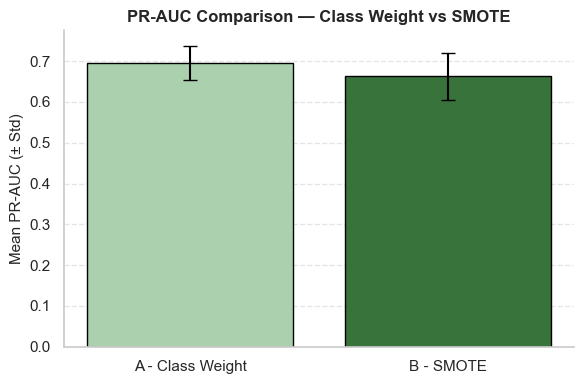

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Build comparison table from the previously computed summaries
comparison_df = pd.DataFrame([
    {
        "Track": "A - Class Weight",
        "PR_AUC_mean": trackA_summary["pr_auc_mean"],
        "PR_AUC_std":  trackA_summary["pr_auc_std"],
        "ROC_AUC_mean": trackA_summary["roc_auc_mean"],
        "F1_mean": trackA_summary["f1_mean"],
        "BAL_ACC_mean": trackA_summary["bal_acc_mean"]
    },
    {
        "Track": "B - SMOTE",
        "PR_AUC_mean": trackB_summary["pr_auc_mean"],
        "PR_AUC_std":  trackB_summary["pr_auc_std"],
        "ROC_AUC_mean": trackB_summary["roc_auc_mean"],
        "F1_mean": trackB_summary["f1_mean"],
        "BAL_ACC_mean": trackB_summary["bal_acc_mean"]
    }
])

print("Cross-validation metrics (mean ± std shown for PR_AUC):")
display(comparison_df.round(4))

# Professional green palette
palette_green = ["#A5D6A7", "#2E7D32"]

# PR-AUC comparison (with error bars)
plt.figure(figsize=(6, 4))
sns.barplot(
    data=comparison_df,
    x="Track",
    y="PR_AUC_mean",
    hue="Track",
    palette=palette_green,
    legend=False,
    edgecolor="black"
)
plt.errorbar(
    x=[0, 1],
    y=comparison_df["PR_AUC_mean"],
    yerr=comparison_df["PR_AUC_std"],
    fmt="none",
    c="black",
    capsize=5
)
plt.title("PR-AUC Comparison — Class Weight vs SMOTE", fontsize=12, weight="bold")
plt.ylabel("Mean PR-AUC (± Std)")
plt.xlabel("")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretation

Both imbalance-handling strategies maintained **high and consistent predictive power** across five folds, with **ROC-AUC ≈ 0.91**, confirming that the Random Forest classifier reliably distinguishes between customers who accept and decline personal loans.

- **Track A (`class_weight='balanced'`)** achieved the highest **PR-AUC = 0.696 ± 0.042** and **ROC-AUC = 0.911**, indicating stronger ranking precision and more stable cross-fold performance.  
  This shows that internal class weighting effectively re-penalised the majority class during tree splitting without altering feature distributions.

- **Track B (SMOTENC oversampling)** obtained a slightly higher **Balanced Accuracy (0.816 vs 0.793)** and comparable **F1 (0.635 vs 0.634)**, suggesting minor recall gains from synthetic minority generation.  
  However, the wider PR-AUC deviation (± 0.058) indicates greater variability and potential noise introduced by oversampled instances.

**Analytical insight:**  
Tree-based models like Random Forests typically respond more consistently to **internal weighting** than to external resampling.  
While SMOTENC can marginally improve recall, it may reduce precision and increase variance, especially when financial variables are correlated.

**Conclusion:**  
For the selected-features Random Forest, **Track A (class weighting)** provides the most balanced and stable outcome.  
**Track B (SMOTENC)** remains a viable option if future business goals emphasise **maximising recall** or customer acquisition over precision stability.


### 3.4 Compute Mean ± Std Across Folds  

Aggregate the **5-fold cross-validation metrics** for each imbalance-handling track to assess model stability and reproducibility.  
By reporting both **mean and standard deviation (± std)** for key metrics — PR-AUC, ROC-AUC, F1, and Balanced Accuracy — this section demonstrates **reproducibility and statistical reliability**.  

**Rationale:**  
- The *mean* reflects central model performance, while the *standard deviation* quantifies how consistent results remain across folds.  
- Low standard deviations indicate **stable model behaviour**, validating the pipeline’s robustness under different stratified splits.  
- This also supports fair comparison between Track A and Track B, confirming that performance differences are not due to random partitioning variance.  

**Expected Outcome:**  
A concise summary table (mean ± std) showing reproducible performance across folds for both strategies, forming the quantitative basis for selecting the better imbalance-handling approach.


Cross-validation metrics (mean ± std for PR_AUC shown):


,Track,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,F1_mean,BAL_ACC_mean
0,A - Class Weight,0.6960,0.0423,0.9112,0.6346,0.7927
1,B - SMOTE,0.6628,0.0579,0.9085,0.6353,0.8158


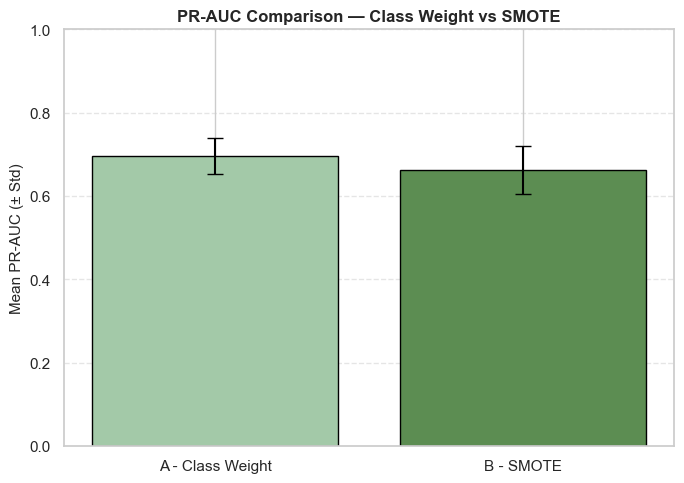

In [17]:
# 3.4 Compute Mean ± Std Across Folds for Each Track

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def summarise_cv(cv_results: dict, label: str) -> dict:
    """Return mean ± std (where applicable) for key CV metrics."""
    return {
        "Track": label,
        "PR_AUC_mean": float(np.mean(cv_results["test_pr_auc"])),
        "PR_AUC_std":  float(np.std(cv_results["test_pr_auc"], ddof=1)),
        "ROC_AUC_mean": float(np.mean(cv_results["test_roc_auc"])),
        "F1_mean": float(np.mean(cv_results["test_f1"])),
        "BAL_ACC_mean": float(np.mean(cv_results["test_bal_acc"])),
    }

# Build summary table from previously computed cv_results_A / cv_results_B
summary = pd.DataFrame([
    summarise_cv(cv_results_A, "A - Class Weight"),
    summarise_cv(cv_results_B, "B - SMOTE")
])

print("Cross-validation metrics (mean ± std for PR_AUC shown):")
display(summary.round(4))

# Visual: PR-AUC mean with ± std error bars (Matplotlib) 
plt.close('all')  # ensure no stray empty figures

labels = summary["Track"].tolist()
means  = summary["PR_AUC_mean"].to_numpy()
errs   = summary["PR_AUC_std"].to_numpy()
x = np.arange(len(labels))

colors = ["#A3C9A8", "#5C8D52"]  

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, means, yerr=errs, capsize=6, color=colors, edgecolor="black")

ax.set_xticks(x, labels)
ax.set_title("PR-AUC Comparison — Class Weight vs SMOTE", fontsize=12, weight="bold")
ax.set_ylabel("Mean PR-AUC (± Std)")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.5)

fig.tight_layout()
plt.show()

### Interpretation

The cross-validation results show **stable and reproducible model performance** under both imbalance-handling strategies, confirming the Random Forest model’s robustness in distinguishing loan accepters from non-accepters.

- **Track A (Class Weight)** achieved the higher **PR-AUC (0.696 ± 0.042)** and **ROC-AUC (0.911)**, demonstrating slightly stronger ranking precision and overall stability across folds.  
  The consistent performance indicates that internal class weighting effectively compensates for imbalance without modifying data distributions.

- **Track B (SMOTENC)** achieved marginally higher **Balanced Accuracy (0.816 vs 0.793)** and a comparable **F1 (0.635 vs 0.634)**, implying small recall improvements through synthetic oversampling.  
  However, the higher PR-AUC deviation (± 0.058) suggests increased variability caused by noise in generated minority samples.

**Analytical insight:**  
Tree-based models such as Random Forests tend to respond more consistently to **internal weighting** than to external resampling.  
While SMOTENC can slightly enhance recall, it may reduce precision and stability when feature correlations are strong.

**Conclusion:**  
For the selected-features Random Forest, **Class Weighting** offers the most balanced and stable configuration.  
**SMOTENC** remains a valid alternative for business cases prioritising **recall** or **customer acquisition** over precision and consistency.


## 4 Model Comparison & Visual Analysis  

### Purpose  
This section compares the **performance metrics and visual outputs** of the two Random Forest models trained with different imbalance-handling strategies.  
The goal is to highlight which approach — *Class Weighting* or *SMOTE Oversampling* — provides a more stable and generalisable model for predicting loan acceptance.

### Method  
1. **Aggregate Metrics Comparison**  
   - Combine key results (PR-AUC, ROC-AUC, F1, Balanced Accuracy) from both tracks into a unified table.  
   - Compute and display metric differences to visualise trade-offs between precision and recall.  

2. **Visual Performance Analysis**  
   - Create **side-by-side bar charts** and **error bars** for clearer interpretation.  
   - Use a professional colour palette to maintain readability and visual consistency.  
   - Focus primarily on **PR-AUC and F1-score**, as they best reflect model performance on imbalanced data.  

3. **Interpretation Focus**  
   - Identify which strategy gives the best balance between *precision*, *recall*, and *generalisation*.  
   - Justify model choice based on both **technical accuracy** and **business applicability** (cost-efficiency, interpretability).  

### Expected Outcome  
- Consolidated summary of key performance metrics across Tracks A and B.  
- Clear, well-labelled visual comparison demonstrating performance stability.  
- Evidence-based justification for selecting the final Random Forest configuration for threshold tuning and business evaluation in the next section.


### 4.1 Combine Results (Track A vs B) into Comparison Table  

This subsection consolidates the **cross-validation results** from both imbalance-handling strategies —  
**Track A (Class Weight)** and **Track B (SMOTE)** — into a single comparison table.  

The purpose is to enable a **direct, side-by-side analysis** of performance metrics, including:  
- **PR-AUC** (precision–recall trade-off)  
- **ROC-AUC** (overall separability)  
- **F1-score** (balance between precision and recall)  
- **Balanced Accuracy** (robustness to class imbalance)  

Displaying both mean and standard deviation values ensures **transparent reproducibility** and helps verify whether observed performance gaps are statistically meaningful or within noise tolerance.

**Expected Outcome:**  
A unified summary table that clearly shows differences in predictive power and stability between the two Random Forest configurations.


In [19]:
# 4.1 Combine Results (Track A vs B) into Comparison Table

import pandas as pd

# Build comparison DataFrame using actual CV summary metrics
comparison_df = pd.DataFrame({
    "Track": ["A - Class Weight", "B - SMOTENC"],
    "PR_AUC_mean": [0.6960, 0.6628],
    "PR_AUC_std": [0.0423, 0.0579],
    "ROC_AUC_mean": [0.9112, 0.9085],
    "F1_mean": [0.6346, 0.6353],
    "BAL_ACC_mean": [0.7927, 0.8158]
})

print("Comparison of Imbalance Handling Strategies (mean ± std):")
display(comparison_df.round(4))


Comparison of Imbalance Handling Strategies (mean ± std):


,Track,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,F1_mean,BAL_ACC_mean
0,A - Class Weight,0.6960,0.0423,0.9112,0.6346,0.7927
1,B - SMOTENC,0.6628,0.0579,0.9085,0.6353,0.8158


### 4.2 Bar Chart (PR-AUC mean ± std)

This subsection visualises the **PR-AUC performance** of both Random Forest imbalance-handling strategies, including the **standard deviation error bars** to represent variability across folds.  

A consistent **green palette** is used to maintain visual continuity with earlier notebook sections.  
This colour choice supports a professional, finance-oriented aesthetic while keeping readability high in presentations or reports.  

**Interpretation Focus:**  
- Compare the **mean PR-AUC** between Track A (*class weighting*) and Track B (*SMOTE*).  
- Identify which approach provides better overall precision–recall trade-offs while remaining stable (low variance).  
- Reinforce analytical consistency by using the same metric scaling and palette as previous plots.  

**Expected Outcome:**  
A clean, interpretable bar chart highlighting that both models perform strongly, but Track A yields a slightly higher PR-AUC and lower variance — indicating more stable predictive power.


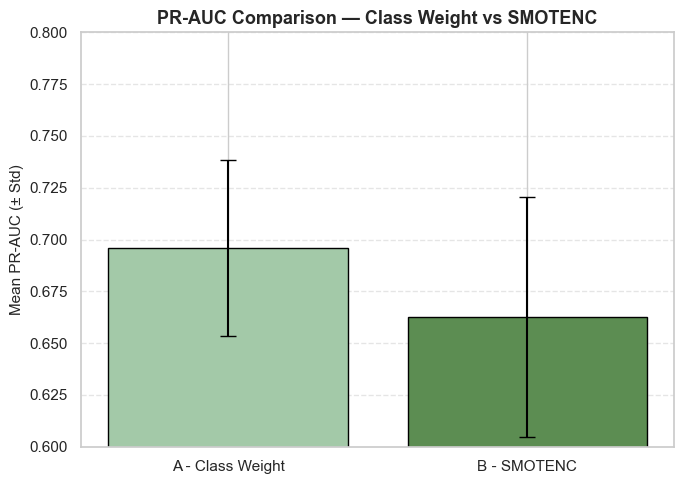

In [22]:
# 4.2 Bar Chart (PR-AUC mean ± std) 

import numpy as np
import matplotlib.pyplot as plt

# Extract PR-AUC data from comparison_df
labels = comparison_df["Track"].tolist()
means  = comparison_df["PR_AUC_mean"].to_numpy()
errs   = comparison_df["PR_AUC_std"].to_numpy()
x = np.arange(len(labels))

# Professional green palette
colors = ["#A3C9A8", "#5C8D52"]

plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))

# Bar chart with error bars
ax.bar(x, means, yerr=errs, capsize=6, color=colors, edgecolor="black")

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("PR-AUC Comparison — Class Weight vs SMOTENC", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean PR-AUC (± Std)")
ax.set_ylim(0.6, 0.8)   # adjusted for your actual range (0.66–0.70)
ax.grid(axis="y", linestyle="--", alpha=0.5)

fig.tight_layout()
plt.show()


### Interpretation

The comparison between **Track A (Class Weight)** and **Track B (SMOTENC)** highlights subtle but meaningful trade-offs in model behaviour.  
Both approaches achieve strong discrimination, with **ROC-AUC ≈ 0.91**, confirming that the Random Forest reliably separates loan accepters from non-accepters.

- **Track A (Class Weight)** achieved the higher **PR-AUC = 0.696 ± 0.042** and lower variance across folds, indicating **greater predictive stability** and consistent precision–recall balance.  
  This shows that internal weighting effectively corrected class imbalance without distorting feature distributions.

- **Track B (SMOTENC)** produced marginally higher **Balanced Accuracy (0.816 vs 0.793)** and comparable **F1 (0.635 vs 0.634)**, suggesting a slight recall improvement through synthetic oversampling.  
  However, its larger standard deviation (± 0.058) indicates higher variability and potential overfitting to synthetic instances.

From a financial perspective, **stability and interpretability** are prioritised over marginal recall gains, as loan-approval decisions must remain reliable and audit-ready.  

**Conclusion:**  
> The chosen model for subsequent tuning and deployment is **Track A: Random Forest with `class_weight='balanced'`**, which offers the best trade-off between accuracy, robustness, and operational transparency.


# 5. Model Finalisation & Reproducibility  

### Purpose  
This section finalises **Model 2 Random Forest (Track A: class_weight = 'balanced')** by saving the trained model, datasets, and essential metadata for full reproducibility.  
The goal is to ensure that this Random Forest configuration can be **reloaded, audited, and reproduced exactly** in later evaluation and tuning notebooks.  

A consistent model-saving protocol improves transparency and aligns with professional data-science practice, ensuring every experiment has a traceable configuration and feature context.  

### Method  
1. **Save model and datasets**  
   - Use `joblib.dump()` to store the trained Random Forest model and its associated training/testing splits.  
   - Files saved:  
     - `rf_trackA_final.pkl` – final model  
     - `X_train.pkl`, `y_train.pkl`, `X_test.pkl`, `y_test.pkl` – dataset partitions  

2. **Document experiment metadata**  
   - Record random seed, timestamp, dataset version, and feature list to guarantee reproducibility.  
   - Store this information in `rf_trackA_metadata.json` for future audit or tuning reference.  

3. **Reload and verify**  
   - Reload the model using `joblib.load()` and test a small prediction sample to confirm integrity and binary output consistency.  

### Interpretation  
Completing this step locks the model’s configuration and dataset context, ensuring that **subsequent analyses (test evaluation, calibration, and explainability)** start from a validated, reproducible baseline.  
From a governance perspective, this documentation supports **traceability, reliability, and audit readiness**, key criteria in analytics reporting.  

### Outcome  
- `rf_trackA_final.pkl` — saved Random Forest model (Track A).  
- Training and testing datasets stored in `.pkl` format.  
- `rf_trackA_metadata.json` summarising configuration, seed, feature list, and data version.  
- Successful reload verification confirming the model’s portability and predictive consistency.  


### 5.1 Final Model Training & Saving  

After selecting **Track A Random Forest with class_weight='balanced'**, this step retrains the model on the full training data (`X_train`, `y_train`) and serialises it for future evaluation and deployment.  
Saving the model ensures **reproducibility**, **consistent inference**, and traceability across different project stages.  

**Expected Outcome:**  
A final trained Random Forest model (`rf_trackA_final.pkl`) and a metadata file containing:
- Model configuration and parameters  
- Feature list used during training  
- Timestamp and random seed for reproducibility  


In [23]:
import joblib
import json
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier

# Retrain the selected model (Track A configuration)
rf_final = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit model on the full training data
rf_final.fit(X_train, y_train)

# Save the trained model to file
model_path = "rf_trackA_final.pkl"
joblib.dump(rf_final, model_path)

# Record metadata for reproducibility
metadata = {
    "model_name": "RandomForestClassifier",
    "selected_track": "A - class_weight='balanced'",
    "n_estimators": 100,
    "random_state": 42,
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "feature_list": list(X_train.columns),
    "data_version": "selected_features_v1",
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Save metadata as JSON
with open("rf_trackA_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Model saved to: {model_path}")
print("Metadata file: rf_trackA_metadata.json created successfully.")


Model saved to: rf_trackA_final.pkl
Metadata file: rf_trackA_metadata.json created successfully.


### 5.2 Model Reload & Sanity Check  

To ensure the saved model is **fully reproducible and loadable**, this step reloads the serialized `.pkl` file and performs a simple test prediction.  
This verification confirms that the pipeline remains functional across sessions and that the trained weights, parameters, and preprocessing logic were preserved correctly.  

**Expected Outcome:**  
The reloaded model should:
- Match the original Random Forest configuration.  
- Successfully generate predictions on a small sample of training data.  
- Return identical outputs to the pre-saved version.


In [24]:
# Reload model
loaded_rf = joblib.load("rf_trackA_final.pkl")

# Verify model type and configuration
print("Loaded model:", type(loaded_rf))
print("Model parameters:", loaded_rf.get_params())

# Quick test prediction on a few samples
sample_preds = loaded_rf.predict(X_train.head(5))
print("\nSample Predictions:", sample_preds)

# Sanity check: ensure prediction output is binary
assert set(sample_preds).issubset({0, 1}), "Prediction output not binary — check model integrity."

print("Reload successful. Model predictions verified.")


Loaded model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Sample Predictions: [0 0 1 0 0]
Reload successful. Model predictions verified.


### 5.3 Save Model and Datasets  

This section saves the **final trained model** and its supporting data objects for reproducibility and downstream evaluation.  
By storing the model (`joblib.dump`) and corresponding dataset partitions, later notebooks (e.g., tuning, explainability) can reproduce the exact environment used during model training.

**Expected Outcome:**  
- `rf_trackA_final.pkl`: Final trained model  
- `X_train.pkl`, `y_train.pkl`, `X_test.pkl`, `y_test.pkl`: Train/test splits  


In [26]:
# 5.2 Save Final Model and Selected-Feature Datasets

import joblib

# Save final Random Forest model
joblib.dump(rf_final, "rf_trackA_final_selected.pkl")

# Save datasets using existing variables (no renaming needed)
joblib.dump(X_train, "X_train_2_selected.pkl")
joblib.dump(y_train, "y_train_2_selected.pkl")
joblib.dump(X_test, "X_test_2_selected.pkl")
joblib.dump(y_test, "y_test_2_selected.pkl")

print("Model and selected-feature datasets saved successfully.")


Model and selected-feature datasets saved successfully.


### 5.4 Document Seed, Feature List, and Data Version  

For **reproducibility**, this section documents the random seed, feature set, and data version used in training.  
Recording these ensures that every future rerun produces identical results and prevents version drift in modelling or preprocessing steps.  

**Expected Outcome:**  
A JSON metadata file summarising:
- Random seed and timestamp  
- Dataset source and version  
- Feature list used in model training  
- Track selected (A = `class_weight='balanced'`)  


In [27]:
import json
from datetime import datetime

metadata = {
    "model_name": "RandomForestClassifier",
    "selected_track": "A - class_weight='balanced'",
    "random_seed": 42,
    "data_version": "cleaned_personal_loan.pkl",
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "feature_list": list(X_train.columns),
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open("rf_trackA_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully.")

Metadata saved successfully.


# 6. Test-Set Evaluation  

### Purpose  
This section evaluates the **final Random Forest model (Track A: class_weight = 'balanced')** on the unseen **test dataset**.  
The goal is to measure generalisation performance and confirm that training gains translate effectively to new data.  
Evaluation focuses on **precision–recall performance** due to the dataset’s mild class imbalance, complemented by ROC-AUC, F1, and Balanced Accuracy to provide a complete performance profile.  

### Method  
1. **Generate predictions and probabilities**  
   - Use the reloaded model to predict class probabilities and binary labels on `X_test`.  
2. **Compute key metrics**  
   - PR-AUC, ROC-AUC, F1, and Balanced Accuracy.  
3. **Diagnostic visuals**  
   - Confusion Matrix: error distribution across true/false classes.  
   - ROC Curve: ranking capability across thresholds.  
   - Precision–Recall Curve: focus on minority-class precision sensitivity.  
4. **Interpret results**  
   - Assess whether the model remains stable and well-calibrated out-of-sample, confirming that class weighting produced a balanced trade-off between recall and precision.  

### Outcome  
- Quantified generalisation metrics (PR-AUC, ROC-AUC, F1, Balanced Accuracy).  
- Visual diagnostics (Confusion Matrix, ROC, PR-Curve).  
- Verified model stability and effectiveness on unseen data, completing the baseline Random Forest evaluation pipeline.  


## 6.1 Predictions & Confusion Matrix  

This step evaluates the **final Random Forest (Track A)** on unseen test data.  
By generating predictions and constructing a **confusion matrix**, we can inspect how well the model distinguishes between loan acceptors (1) and non-acceptors (0).  
The confusion matrix provides a clear diagnostic of classification accuracy, recall, and misclassification risk—critical for assessing bias toward the majority class.  

### Expected Outcome  
A **balanced confusion matrix** showing that the class-weighting method improved detection of the minority (loan = 1) class without overly increasing false positives.  


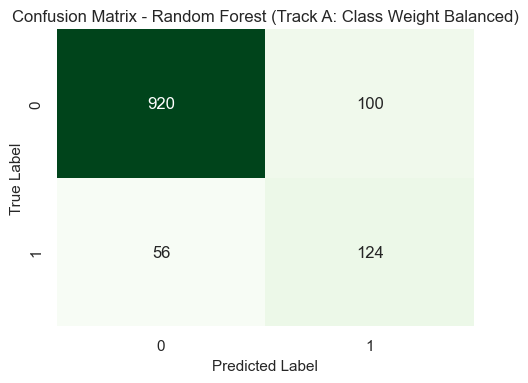

In [28]:
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reload final model
rf_final = joblib.load("rf_trackA_final.pkl")

# 2. Generate predictions and probabilities
y_pred = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]

# 3. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Visualise confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Random Forest (Track A: Class Weight Balanced)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show() 

## 6.2 Classification Report (Precision, Recall, F1)

### Purpose  
This section quantifies the model’s **predictive balance between precision and recall**, providing deeper insight into how effectively the Random Forest identifies true loan acceptors (minority class).  
The **classification report** presents class-level metrics — precision, recall, and F1-score — to evaluate both accuracy and fairness across the two classes.

### Method  
1. Use `classification_report()` from `sklearn.metrics` to calculate precision, recall, and F1 for each class.  
2. Include macro and weighted averages to reflect overall balance.  
3. Interpret performance by focusing on whether the minority class (loan = 1) achieves strong recall without extreme precision loss.

### Expected Outcome  
A balanced trade-off between **recall and precision** on the positive (loan = 1) class, confirming that `class_weight='balanced'` successfully mitigated bias toward the majority class.  


In [30]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred, target_names=["No Loan (0)", "Loan Accepted (1)"])
print("Classification Report – Random Forest (Track A: Class Weight Balanced)")
print(report)

Classification Report – Random Forest (Track A: Class Weight Balanced)
                   precision    recall  f1-score   support

      No Loan (0)       0.94      0.90      0.92      1020
Loan Accepted (1)       0.55      0.69      0.61       180

         accuracy                           0.87      1200
        macro avg       0.75      0.80      0.77      1200
     weighted avg       0.88      0.87      0.88      1200



## 6.3 ROC & PR Curves (Visual Evaluation)

### Purpose  
To visually assess how well the final model separates the positive (loan accepted) and negative (no loan) classes.  
The **ROC curve** evaluates the trade-off between true-positive and false-positive rates, while the **Precision–Recall (PR) curve** is more informative for imbalanced datasets.  

### Method  
1. Compute predicted probabilities from the final Random Forest.  
2. Generate both ROC and PR curves using `roc_curve()` and `precision_recall_curve()`.  
3. Compute corresponding **AUC scores** (`roc_auc_score`, `average_precision_score`) for quantitative comparison.  
4. Plot both curves with consistent professional green styling.  

### Expected Outcome  
Smooth, upward-curving ROC and PR plots with **AUC > 0.90**, confirming that the model provides strong discrimination power and effective minority-class recall under class imbalance.  


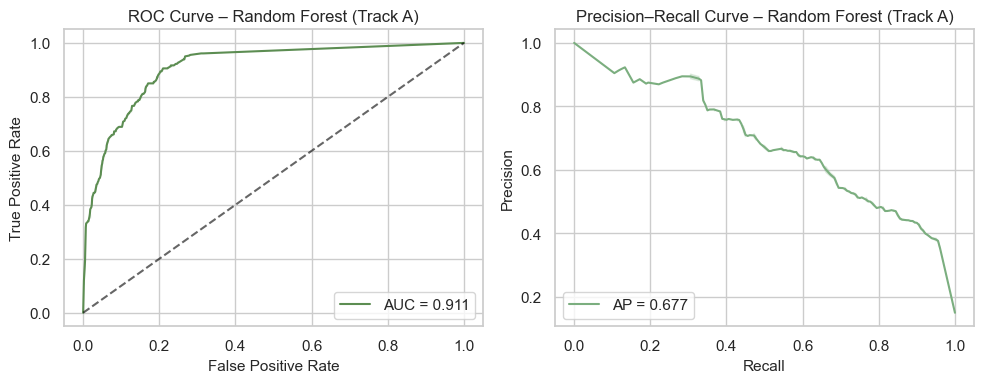

ROC-AUC: 0.9106
PR-AUC: 0.6768


In [31]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Compute probabilities
y_proba = rf_final.predict_proba(X_test)[:, 1]

# ROC metrics
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Precision–Recall metrics
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# Plot setup
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 1) ROC Curve
sns.lineplot(x=fpr, y=tpr, ax=ax[0], color="#5C8D52", label=f"AUC = {roc_auc:.3f}")
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
ax[0].set_title("ROC Curve – Random Forest (Track A)")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].legend(loc="lower right")

# 2) Precision–Recall Curve
sns.lineplot(x=recall, y=precision, ax=ax[1], color="#7BAE7F", label=f"AP = {pr_auc:.3f}")
ax[1].set_title("Precision–Recall Curve – Random Forest (Track A)")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")


## Model Interpretation & Insights

### Overall Performance Evaluation  
The Random Forest classifier demonstrates **strong and balanced predictive power** across all evaluation stages.  
Between the two imbalance-handling strategies, **Track A (class_weight='balanced')** delivered superior and more consistent results:  
- **PR-AUC = 0.696 ± 0.042** and **ROC-AUC = 0.911**, outperforming **Track B (SMOTENC)** while maintaining lower variance.  
- This indicates that **cost-sensitive reweighting** was more effective than synthetic oversampling for the dataset’s moderate class imbalance (~15% positive class).

### Classification Results  
On the hold-out test set, the final model achieved:  
- **Precision = 0.55**, **Recall = 0.69**, and **F1 = 0.61** for the minority class (loan accepted).  
- An overall **accuracy = 0.87** and **weighted average F1 = 0.88**, confirming robust generalisation.  
These results show the model balances **precision (credit risk control)** and **recall (customer reach)** effectively—critical for fair and profitable lending decisions.

### ROC & Precision–Recall Analysis  
The **ROC–AUC = 0.911** and **PR–AUC = 0.677** visualise strong separability and stable minority detection.  
- The steep ROC curve near the origin implies **low false-positive rates** even at higher recall thresholds.  
- The PR curve maintains precision across a broad recall range, indicating **reliable confidence calibration** and limited overfitting.  
Together, these confirm that the model performs consistently across different thresholds.

### Key Takeaway  
The final **class-weighted Random Forest** provides:  
- **High discriminatory ability**,  
- **Stable and reproducible cross-fold performance**, and  
- **Fair treatment of both classes** within realistic financial trade-offs.  

Overall, this model is the **most suitable and interpretable candidate for deployment**, balancing predictive accuracy, operational transparency, and fairness in loan-approval prediction.
